In [ ]:

# construct observables, improved version
opsX = []
sitesA = []
for i in range(Nu):
    a_site = i
    opsX.append(sigmax.tolist())
    sitesA.append([a_site])
    
    d_site = a_site + dshift 
    opsX.append(sigmax.tolist())
    sitesA.append([d_site])
# A sublattice magnetization, Neel order, x component    
sxA = nk.operator.LocalOperator(hi, opsX, sitesA)

sitesB = []
for i in range(Nu):
    b_site = a_site + bshift 
    sitesB.append([b_site])

    c_site = a_site + cshift 
    sitesB.append([c_site])
# B sublattice    
sxB = nk.operator.LocalOperator(hi, opsX, sitesB)

opsY = []
# sitesA remain the same
for i in range(Nu):
    opsY.append(sigmay.tolist())
    opsY.append(sigmay.tolist())
syA = nk.operator.LocalOperator(hi, opsY, sitesA)
syB = nk.operator.LocalOperator(hi, opsY, sitesB)

opsZ = []
for i in range(Nu):
    opsZ.append(sigmaz.tolist())
    opsZ.append(sigmaz.tolist())
szA = nk.operator.LocalOperator(hi, opsZ, sitesA)
szB = nk.operator.LocalOperator(hi, opsZ, sitesB)

# horizontal bonds
# even
opsA = []
sitesA = []
# odd
opsB = []
sitesB = []
for i in range(Nu):
    a_site = i
    b_site = a_site + bshift
    opsA.append(ss.tolist())
    sitesA.append([a_site, b_site])
    
    [m,n] = g.site_to_vector(i) 
    # a_prime site move to right by one step
    a_prime = g.vector_to_site([m,(n+1)%L])
    opsB.append(ss.tolist())
    sitesB.append([b_site, a_prime])
    
    c_site = a_site + cshift 
    d_site = a_site + dshift 
    opsA.append(ss.tolist())
    sitesA.append([c_site, d_site])
    
    c_prime = a_prime + cshift 
    opsB.append(ss.tolist())
    sitesB.append([d_site, c_prime])    
BxA = nk.operator.LocalOperator(hi, opsA, sitesA)
BxB = nk.operator.LocalOperator(hi, opsB, sitesB)

# vertical bonds, even and odd
opsA = []
sitesA = []
opsB = []
sitesB = []
for i in range(Nu):
    a_site = i
    c_site = a_site + cshift
    opsA.append(ss.tolist())
    sitesA.append([a_site, c_site])
    
    [m,n] = g.site_to_vector(i) 
    # a_prime site move up by one step
    a_prime = g.vector_to_site([(m+1)%L, n])
    opsB.append(ss.tolist())
    sitesB.append([c_site, a_prime])
    
    b_site = a_site + bshift 
    d_site = a_site + dshift 
    opsA.append(ss.tolist())
    sitesA.append([b_site, d_site])
    
    b_prime = a_prime + bshift 
    opsB.append(ss.tolist())
    sitesB.append([d_site, b_prime])    
ByA = nk.operator.LocalOperator(hi, opsA, sitesA)
ByB = nk.operator.LocalOperator(hi, opsB, sitesB)

# energy of diagonal bonds, /
opsA = []
sitesA = []
# diagonal, \
opsB = []
sitesB = []
#loop over unit cells
for i in range(Nu):
    a_site = i
    d_site = a_site + dshift 
    opsA.append(ss.tolist())
    sitesA.append([a_site, d_site])
    
    # site b, not the same unit cell, shift to left and up
    [m,n] = g.site_to_vector(i)
    b_site = g.vector_to_site([(m+1)%L,(n-1)%L]) + bshift
    c_site = a_site + cshift 
    opsB.append(ss.tolist())
    sitesB.append([c_site, b_site])    
DiagA = nk.operator.LocalOperator(hi, opsA, sitesA)
# B should come with minus sign
DiagB = nk.operator.LocalOperator(hi, opsB, sitesB)

# new way, computing the obserbables take time!
observers = {"DiagA": DiagA, "DiagB": DiagB, "BxA": BxA, "ByA": ByA, "BxB": BxB, "ByB": ByB, "SxA": sxA, "SyA": syA, "SzA": szA, "SxB": sxB, "SyB": syB, "SzB": szB}

In [1]:
# J1-J3 model, with J2=0
# summer 2023

import math
import numpy as np
import netket as nk
import matplotlib.pyplot as plt
import json
import sys

import netket.nn as nknn
import flax.linen as nn
import jax.numpy as jnp

# number of unit cells L*L
L = 4

# set up the square lattice, notice the sequence of the basis vectors
g=nk.graph.Lattice(basis_vectors=[[0,1],[1,0]],extent=[L,L],
                   pbc=[False,False], max_neighbor_order = 3) 

# number of sites
Nsites=g.n_nodes

# Hilbert space for spin 1/2, confined to S_z=0
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)

# Pauli Matrices
sigmaz = np.array([[1, 0], [0, -1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])

# manually set up Heisenberg exchange, spin 1/2
ss = np.kron(sigmax,sigmax) + np.kron(sigmay,sigmay) + np.kron(sigmaz,sigmaz)

# J1=1
J1 = 1
# J3/J1 will be varied
J3 = 0.25

# nearest neighbor, and next-next nearest neighbor
bond_color = [0, 2]
bond_operator = [(J1 * ss).tolist(), (J3 * ss).tolist()]

# Custom J1-J3 Hamiltonian, constructed as an operator
ham = nk.operator.GraphOperator(hi, graph=g, bond_ops=bond_operator, bond_ops_colors=bond_color)

#Feature dimensions of hidden layers, from first to last
#feature_dims = (8,8,8,8)
#Number of layers
#num_layers = 4
#symmetries = g.automorphisms()
#Define the GCNN 
#ma = nk.models.GCNN(symmetries = symmetries, layers = num_layers, features = feature_dims)

class FFNN(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=2*x.shape[-1], 
                     use_bias=True, 
                     param_dtype=np.complex128, 
                     kernel_init=nn.initializers.normal(stddev=0.01), 
                     bias_init=nn.initializers.normal(stddev=0.01)
                    )(x)
        x = nknn.log_cosh(x)
        x = jnp.sum(x, axis=-1)
        return x
        
ma = FFNN()

#Metropolis-Hastings with two spins flipped that are at most second nearest neighbors 
sa = nk.sampler.MetropolisExchange(hilbert = hi, graph=g, d_max=2)

#Stochastic reconfiguration   
op = nk.optimizer.Sgd(learning_rate=1e-2)
sr = nk.optimizer.SR(diag_shift=0.01)

#Define a variational state so we can keep the parameters if we like
vstate = nk.vqs.MCState(sampler=sa, model=ma, n_samples=512)

#Define a driver that performs VMC
gs = nk.driver.VMC(ham, op, sr=sr, variational_state=vstate)

#Run the optimization
gs.run(n_iter=1000, out='out')

100%|██████████| 1000/1000 [01:34<00:00, 10.58it/s, Energy=-24.00-0.04j ± 0.15 [σ²=11.67, R̂=1.0283]]     


(JsonLog('out', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.3495488166809082
   	Params: 0.015951156616210938,)

In [6]:
gs.run(n_iter=2000, out='out')

100%|██████████| 2000/2000 [03:47<00:00,  8.79it/s, Energy=-31.843+0.024j ± 0.058 [σ²=1.748, R̂=1.0252]]


(JsonLog('out', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.8903076648712158
   	Params: 0.03599238395690918,)

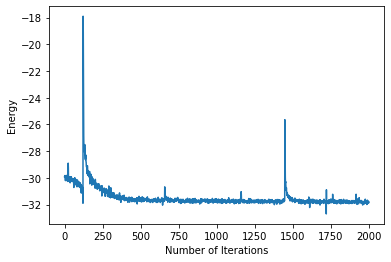

In [7]:
#Get data from log and 
energy = []
data=json.load(open("out.log"))

iters = data['Energy']['iters']
energy=data['Energy']['Mean']['real']

#plot the energy during the optimization
plt.xlabel("Number of Iterations")
plt.ylabel("Energy")

plt.plot(energy)

In [5]:
# exact diagonalization
evals = nk.exact.lanczos_ed(ham, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is E0=',exact_gs_energy)

The exact ground-state energy is E0= -34.53220764538808


<AxesSubplot:>

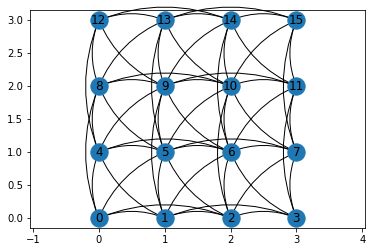

In [7]:
g.draw()

In [8]:
print(g.edges(filter_color=0))

[(3, 7), (12, 13), (8, 9), (8, 12), (13, 14), (4, 5), (5, 6), (4, 8), (5, 9), (14, 15), (0, 1), (9, 10), (1, 2), (0, 4), (9, 13), (10, 11), (1, 5), (10, 14), (6, 7), (6, 10), (2, 3), (2, 6), (11, 15), (7, 11)]


In [22]:
#Use Netket to find symmetries of the graph
symmetries = g.automorphisms()

#Check that graph info is correct
print(g.n_nodes)
print(g.n_edges)
print(len(symmetries))

16
58
8


In [15]:
print(g.edges(filter_color=1))

[(10, 15), (2, 7), (5, 8), (4, 9), (6, 11), (7, 10), (9, 12), (11, 14), (1, 4), (10, 13), (8, 13), (5, 10), (0, 5), (3, 6), (9, 14), (1, 6), (2, 5), (6, 9)]


In [16]:
print(g.edges(filter_color=2))

[(2, 10), (4, 6), (4, 12), (6, 14), (5, 7), (5, 13), (8, 10), (0, 2), (13, 15), (7, 15), (9, 11), (0, 8), (1, 3), (1, 9), (12, 14), (3, 11)]
